In [1]:
import pandas as pd
import statsmodels.formula.api as smf

# Thank you ChatGPT o4-mini-high and Grok 3 and the textbook Python 3 and Feature Engineering by Oswald Campesato for help with this analysis

filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

Descriptive Statistics by Play Type:
              ballCarrierSpeed                                              \
                         count      mean       std   min   25%   50%   75%   
playType                                                                     
Completion           1937856.0  4.427978  2.276057  0.00  2.56  4.41  6.22   
Designed Rush        4208064.0  3.272628  2.523023  0.00  0.92  3.16  5.14   
Scramble              212628.0  6.207134  2.165880  0.03  4.88  6.62  7.93   

                     toPlayerDistanceToBallCarrier                             \
                 max                         count       mean        std  min   
playType                                                                        
Completion     10.50                     1937856.0  14.319110  10.980000  0.0   
Designed Rush  10.80                     4208064.0   8.594581   6.618639  0.0   
Scramble       10.15                      212628.0  14.550473  11.352421  0.0   

       

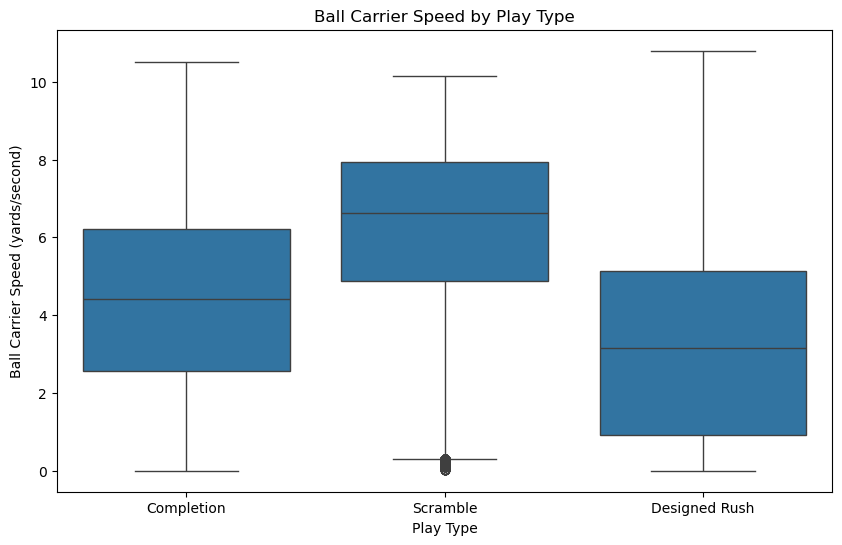

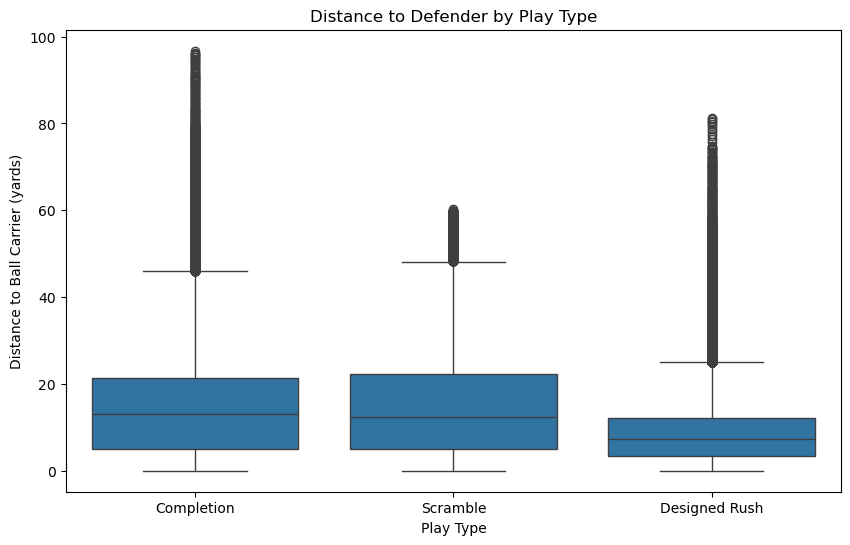

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data (assuming the CSV is saved locally or loaded from the provided text)
# For this example, I'll simulate loading the provided data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Descriptive statistics for ballCarrierSpeed and toPlayerDistanceToBallCarrier by playType
desc_stats = data.groupby('playType')[['ballCarrierSpeed', 'toPlayerDistanceToBallCarrier']].describe()

# Print descriptive statistics
print("Descriptive Statistics by Play Type:")
print(desc_stats)

# Visualization: Box plot of ballCarrierSpeed by playType
plt.figure(figsize=(10, 6))
sns.boxplot(x='playType', y='ballCarrierSpeed', data=data)
plt.title('Ball Carrier Speed by Play Type')
plt.xlabel('Play Type')
plt.ylabel('Ball Carrier Speed (yards/second)')
plt.show()

# Visualization: Box plot of toPlayerDistanceToBallCarrier by playType
plt.figure(figsize=(10, 6))
sns.boxplot(x='playType', y='toPlayerDistanceToBallCarrier', data=data)
plt.title('Distance to Defender by Play Type')
plt.xlabel('Play Type')
plt.ylabel('Distance to Ball Carrier (yards)')
plt.show()

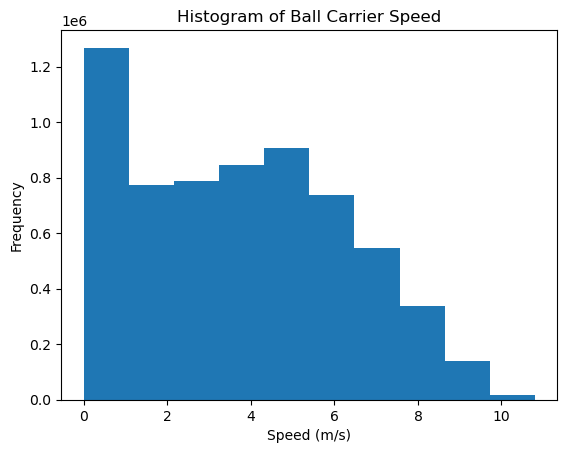

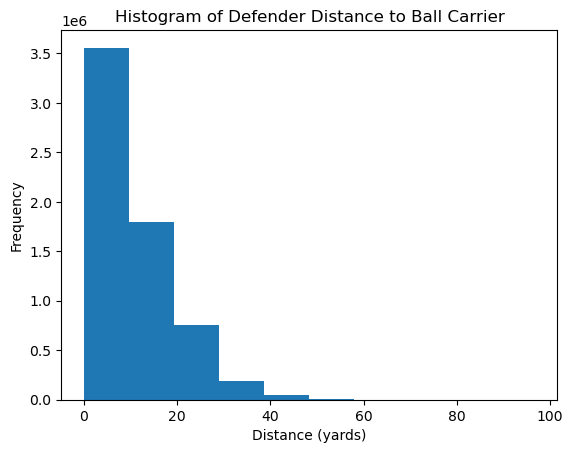

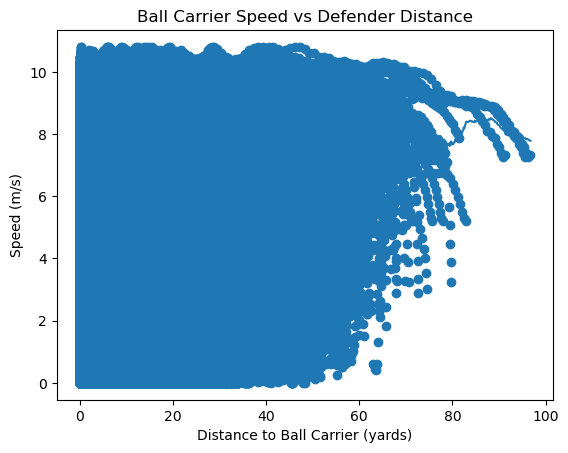

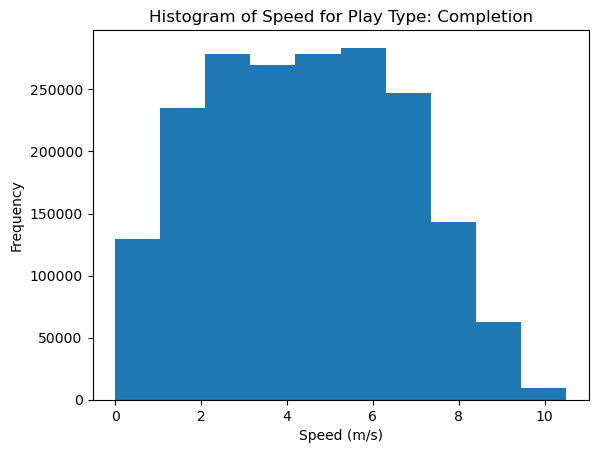

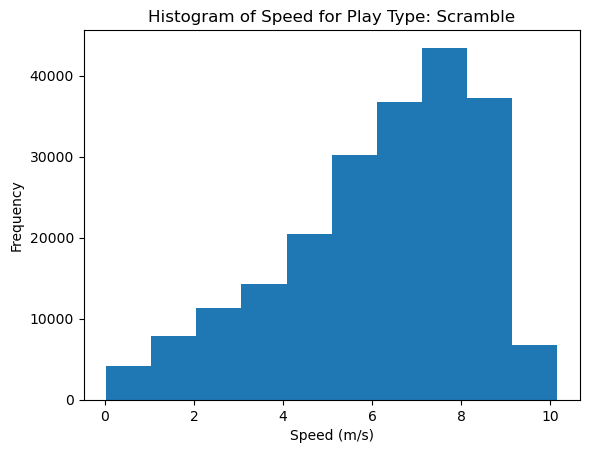

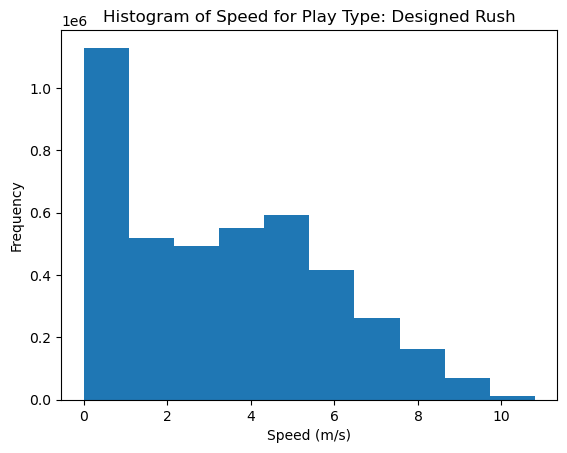

In [4]:

filename="speed_dist_data_20231228.csv"
df = pd.read_csv(filename)

# 1. Histogram of Ball Carrier Speed
plt.figure()
plt.hist(df['ballCarrierSpeed'].dropna())
plt.title('Histogram of Ball Carrier Speed')
plt.xlabel('Speed (m/s)')
plt.ylabel('Frequency')
plt.show()

# 2. Histogram of Distance to Ball Carrier
plt.figure()
plt.hist(df['toPlayerDistanceToBallCarrier'].dropna())
plt.title('Histogram of Defender Distance to Ball Carrier')
plt.xlabel('Distance (yards)')
plt.ylabel('Frequency')
plt.show()

# 3. Scatter Plot with Smoothing: Speed vs Distance
df_sorted = df.sort_values('toPlayerDistanceToBallCarrier')
x = df_sorted['toPlayerDistanceToBallCarrier']
y = df_sorted['ballCarrierSpeed']
y_smooth = y.rolling(window=50, min_periods=1, center=True).mean()

plt.figure()
plt.scatter(x, y)
plt.plot(x, y_smooth)
plt.title('Ball Carrier Speed vs Defender Distance')
plt.xlabel('Distance to Ball Carrier (yards)')
plt.ylabel('Speed (m/s)')
plt.show()

# 4. Breakdown of Speed Distribution by Play Type
play_types = df['playType'].unique()
for pt in play_types:
    subset = df[df['playType'] == pt]
    plt.figure()
    plt.hist(subset['ballCarrierSpeed'].dropna())
    plt.title(f'Histogram of Speed for Play Type: {pt}')
    plt.xlabel('Speed (m/s)')
    plt.ylabel('Frequency')
    plt.show()


In [5]:
# 2. Engineer defender‐density: count of defenders within 5 yards, per frame
df['n_def_5yd'] = (
    df
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d < 5).sum())
)

In [6]:
# 3. Filter to the under 2.5 yard window
df_2yd = df[
    (df['toPlayerDistanceToBallCarrier'] <= 2.5)
].copy()

# 4. Fit OLS: speed ~ proximity + defender density
model = smf.ols(
    'ballCarrierSpeed ~ toPlayerDistanceToBallCarrier + n_def_5yd',
    data=df_2yd
).fit()

# 5. Inspect results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.294
Method:                 Least Squares   F-statistic:                 2.450e+05
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:26:25   Log-Likelihood:            -2.4481e+06
No. Observations:             1178821   AIC:                         4.896e+06
Df Residuals:                 1178818   BIC:                         4.896e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [8]:
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

# Load the data (simulating the CSV load from your provided snippet)
data = pd.read_csv('speed_dist_data_20231228.csv')

# Step 1: Prepare the data
# Encode the categorical variable 'playType' (Completion, Scramble)
label_encoder = LabelEncoder()
data['playType_encoded'] = label_encoder.fit_transform(data['playType'])

# Select independent variables (predictors) and dependent variable
X = data[['toPlayerDistanceToBallCarrier', 'frameId', 'playType_encoded']]
y = data['ballCarrierSpeed']

# Add a constant term for the intercept in the regression model
X = sm.add_constant(X)

# Step 2: Fit the regression model
model = sm.OLS(y, X).fit()

# Step 3: Print the summary of the regression results
print(model.summary())

# Step 4: Extract coefficients for interpretation
coefficients = model.params
print("\nRegression Coefficients:")
for var, coef in coefficients.items():
    print(f"{var}: {coef:.4f}")

                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                 1.654e+05
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:35:41   Log-Likelihood:            -1.4705e+07
No. Observations:             6358548   AIC:                         2.941e+07
Df Residuals:                 6358544   BIC:                         2.941e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [11]:
# combine Grok and ChatGPT approaches

# Load the data (simulating the CSV load from your provided snippet)
data = pd.read_csv('speed_dist_data_20231228.csv')

# Step 1: Prepare the data
# Encode the categorical variable 'playType' (Completion, Scramble)
label_encoder = LabelEncoder()
data['playType_encoded'] = label_encoder.fit_transform(data['playType'])

# add defender swarm
data['n_def_5yd'] = (
    data
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d < 5).sum())
)

# Select independent variables (predictors) and dependent variable
X = data[['toPlayerDistanceToBallCarrier', 'frameId', 'playType_encoded', 'n_def_5yd']]
y = data['ballCarrierSpeed']

# Add a constant term for the intercept in the regression model
X = sm.add_constant(X)



# Step 2: Fit the regression model
model = sm.OLS(y, X).fit()

# Step 3: Print the summary of the regression results
print(model.summary())

# Step 4: Extract coefficients for interpretation
coefficients = model.params
print("\nRegression Coefficients:")
for var, coef in coefficients.items():
    print(f"{var}: {coef:.4f}")

                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.090
Method:                 Least Squares   F-statistic:                 1.580e+05
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:48:57   Log-Likelihood:            -1.4643e+07
No. Observations:             6358548   AIC:                         2.929e+07
Df Residuals:                 6358543   BIC:                         2.929e+07
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

In [12]:

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Encode playType
label_encoder = LabelEncoder()
data['playType_encoded'] = label_encoder.fit_transform(data['playType'])
print("PlayType Encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# Simple regression with just playType_encoded
X = data[['playType_encoded']]
y = data['ballCarrierSpeed']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

PlayType Encoding: {'Completion': 0, 'Designed Rush': 1, 'Scramble': 2}
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                 6.551e+04
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        11:49:55   Log-Likelihood:            -1.4912e+07
No. Observations:             6358548   AIC:                         2.982e+07
Df Residuals:                 6358546   BIC:                         2.982e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

In [14]:
# Use Dummy Variables Instead: Instead of LabelEncoder, let’s use dummy variables for playType to make the coefficients easier to interpret:

import statsmodels.api as sm

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Create dummy variables for playType (Completion as reference)
playtype_dummies = pd.get_dummies(data['playType'], prefix='playType', drop_first=True)
data = pd.concat([data, playtype_dummies], axis=1)

# Regression with dummy variables
X = data[['playType_Designed Rush', 'playType_Scramble']]
y = data['ballCarrierSpeed']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [15]:
import pandas as pd
import statsmodels.api as sm

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Debug: Check data types and first few rows
print("Data Types:\n", data.dtypes)
print("\nFirst 5 Rows:\n", data.head())

# Ensure ballCarrierSpeed is numeric
data['ballCarrierSpeed'] = pd.to_numeric(data['ballCarrierSpeed'], errors='coerce')
print("\nNaNs in ballCarrierSpeed:", data['ballCarrierSpeed'].isna().sum())
data = data.dropna(subset=['ballCarrierSpeed'])  # Drop rows with NaN in ballCarrierSpeed

# Create dummy variables for playType (Completion as reference)
playtype_dummies = pd.get_dummies(data['playType'], prefix='playType', drop_first=True).astype(int)
data = pd.concat([data.drop(columns=playtype_dummies.columns, errors='ignore'), playtype_dummies], axis=1)

# Debug: Check dummy variables
print("\nDummy Variable Types:\n", data[['playType_Designed Rush', 'playType_Scramble']].dtypes)
print("\nFirst 5 Rows of Dummy Variables:\n", data[['playType_Designed Rush', 'playType_Scramble']].head())

# Regression with dummy variables
X = data[['playType_Designed Rush', 'playType_Scramble']]
y = data['ballCarrierSpeed']

# Debug: Check X and y before regression
print("\nX Types:\n", X.dtypes)
print("\nX Head:\n", X.head())
print("\ny Type:", y.dtype)
print("\ny Head:\n", y.head())

# Run regression
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

Data Types:
 gameId                             int64
playId                             int64
frameId                            int64
playType                          object
ballCarrierNflId                   int64
ballCarrierDisplayName            object
ballCarrierJerseyNumber            int64
ballCarrierSpeed                 float64
toPlayerNflId                      int64
toPlayerDisplayName               object
toPlayerDistanceToBallCarrier    float64
toPlayerAction_tackle              int64
toPlayerAction_assist              int64
toPlayerAction_forcedFumble        int64
toPlayerAction_missedTackle        int64
dtype: object

First 5 Rows:
        gameId  playId  frameId    playType  ballCarrierNflId  \
0  2022090800      56        1  Completion             42489   
1  2022090800      56        1  Completion             42489   
2  2022090800      56        1  Completion             42489   
3  2022090800      56        1  Completion             42489   
4  2022090800      56 

In [16]:
import pandas as pd
import statsmodels.api as sm

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Exclude rows where toPlayerNflId is 0 (the football)
data = data[data['toPlayerNflId'] != 0]

# Debug: Check data after filtering
print("Data Types:\n", data.dtypes)
print("\nFirst 5 Rows After Excluding Football:\n", data.head())
print("\nRows After Excluding Football:", len(data))

# Ensure ballCarrierSpeed is numeric
data['ballCarrierSpeed'] = pd.to_numeric(data['ballCarrierSpeed'], errors='coerce')
print("\nNaNs in ballCarrierSpeed:", data['ballCarrierSpeed'].isna().sum())
data = data.dropna(subset=['ballCarrierSpeed'])  # Drop rows with NaN in ballCarrierSpeed

# Create dummy variables for playType (Completion as reference)
playtype_dummies = pd.get_dummies(data['playType'], prefix='playType', drop_first=True).astype(int)
data = pd.concat([data.drop(columns=playtype_dummies.columns, errors='ignore'), playtype_dummies], axis=1)

# Debug: Check dummy variables
print("\nDummy Variable Types:\n", data[['playType_Designed Rush', 'playType_Scramble']].dtypes)
print("\nFirst 5 Rows of Dummy Variables:\n", data[['playType_Designed Rush', 'playType_Scramble']].head())

# Regression with dummy variables
X = data[['playType_Designed Rush', 'playType_Scramble']]
y = data['ballCarrierSpeed']

# Debug: Check X and y before regression
print("\nX Types:\n", X.dtypes)
print("\nX Head:\n", X.head())
print("\ny Type:", y.dtype)
print("\ny Head:\n", y.head())

# Run regression
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

Data Types:
 gameId                             int64
playId                             int64
frameId                            int64
playType                          object
ballCarrierNflId                   int64
ballCarrierDisplayName            object
ballCarrierJerseyNumber            int64
ballCarrierSpeed                 float64
toPlayerNflId                      int64
toPlayerDisplayName               object
toPlayerDistanceToBallCarrier    float64
toPlayerAction_tackle              int64
toPlayerAction_assist              int64
toPlayerAction_forcedFumble        int64
toPlayerAction_missedTackle        int64
dtype: object

First 5 Rows After Excluding Football:
        gameId  playId  frameId    playType  ballCarrierNflId  \
1  2022090800      56        1  Completion             42489   
2  2022090800      56        1  Completion             42489   
3  2022090800      56        1  Completion             42489   
4  2022090800      56        1  Completion             42489 

In [3]:
import pandas as pd
import statsmodels.formula.api as smf

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Exclude rows where toPlayerNflId is 0 (the football)
data = data[data['toPlayerNflId'] != 0]

# Filter to defenders within 2.5 yards
data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()

# Ensure ballCarrierSpeed is numeric
data_2yd['ballCarrierSpeed'] = pd.to_numeric(data_2yd['ballCarrierSpeed'], errors='coerce')
data_2yd = data_2yd.dropna(subset=['ballCarrierSpeed'])

# Engineer defender-density: count of defenders within 5 yards, per frame
# Note: Since we're already filtering to 2.5 yards, we'll adjust this to count defenders within 2.5 yards (already satisfied)
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Debug: Check the filtered data and new feature
print("First 5 Rows of Filtered Data (2.5 yards):\n", data_2yd[['gameId', 'playId', 'frameId', 'toPlayerDistanceToBallCarrier', 'n_def_2_5yd']].head())
print("\nRows After 2.5-yard Filter:", len(data_2yd))

# Fit OLS with additional covariates and fixed effects
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + I(toPlayerDistanceToBallCarrier**2) + '
    'n_def_2_5yd + frameId + '
    'toPlayerAction_tackle + toPlayerAction_assist + '
    'toPlayerAction_forcedFumble + toPlayerAction_missedTackle + '
    'C(playType) + C(gameId)'
)
model = smf.ols(formula, data=data_2yd).fit(cov_type='cluster', cov_kwds={'groups': data_2yd['playId']})

# View the results
print(model.summary())

First 5 Rows of Filtered Data (2.5 yards):
          gameId  playId  frameId  toPlayerDistanceToBallCarrier  n_def_2_5yd
88   2022090800      56        8                        2.30417            1
100  2022090800      56        9                        2.03600            1
112  2022090800      56       10                        1.77102            2
119  2022090800      56       10                        2.25002            2
124  2022090800      56       11                        1.52306            2

Rows After 2.5-yard Filter: 754558
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.404
Model:                            OLS   Adj. R-squared:                  0.404
Method:                 Least Squares   F-statistic:                     125.3
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:13:49   Log-Likelihood:        

In [4]:
import pandas as pd
import statsmodels.formula.api as smf

# Load data
data = pd.read_csv('speed_dist_data_20231228.csv')

# Exclude rows where toPlayerNflId is 0 (the football)
data = data[data['toPlayerNflId'] != 0]

# Filter to defenders within 2.5 yards
data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()

# Ensure ballCarrierSpeed is numeric
data_2yd['ballCarrierSpeed'] = pd.to_numeric(data_2yd['ballCarrierSpeed'], errors='coerce')
data_2yd = data_2yd.dropna(subset=['ballCarrierSpeed'])

# Engineer defender-density: count of defenders within 2.5 yards, per frame
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Debug: Check the filtered data and new feature
print("First 5 Rows of Filtered Data (2.5 yards):\n", data_2yd[['gameId', 'playId', 'frameId', 'toPlayerDistanceToBallCarrier', 'n_def_2_5yd']].head())
print("\nRows After 2.5-yard Filter:", len(data_2yd))

# Fit OLS with simplified covariates and fixed effects
formula = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'C(playType) + C(gameId)'
)
model = smf.ols(formula, data=data_2yd).fit(cov_type='cluster', cov_kwds={'groups': data_2yd['playId']})

# View the results
print(model.summary())

First 5 Rows of Filtered Data (2.5 yards):
          gameId  playId  frameId  toPlayerDistanceToBallCarrier  n_def_2_5yd
88   2022090800      56        8                        2.30417            1
100  2022090800      56        9                        2.03600            1
112  2022090800      56       10                        1.77102            2
119  2022090800      56       10                        2.25002            2
124  2022090800      56       11                        1.52306            2

Rows After 2.5-yard Filter: 754558
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     116.2
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:26:58   Log-Likelihood:        

In [6]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
predictors = data_2yd[['toPlayerDistanceToBallCarrier', 'n_def_2_5yd', 'frameId']].copy()
predictors = sm.add_constant(predictors)
vif_data = pd.DataFrame()
vif_data['Variable'] = predictors.columns
vif_data['VIF'] = [variance_inflation_factor(predictors.values, i) for i in range(predictors.shape[1])]
print(vif_data)

                        Variable        VIF
0                          const  13.108663
1  toPlayerDistanceToBallCarrier   1.010879
2                    n_def_2_5yd   1.255099
3                        frameId   1.260967


In [7]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Load and prepare data
data = pd.read_csv('speed_dist_data_20231228.csv')
data = data[data['toPlayerNflId'] != 0]
data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
data_2yd['ballCarrierSpeed'] = pd.to_numeric(data_2yd['ballCarrierSpeed'], errors='coerce')
data_2yd.dropna(subset=['ballCarrierSpeed'], inplace=True)

# Recompute defender count within 2.5 yards
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Create a single "contact" flag for any event
event_cols = [
    'toPlayerAction_tackle',
    'toPlayerAction_assist',
    'toPlayerAction_forcedFumble',
    'toPlayerAction_missedTackle'
]
data_2yd['contact'] = (data_2yd[event_cols].sum(axis=1) > 0).astype(int)

# 2. Define model formulas
formula_mt = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'toPlayerAction_missedTackle + '
    'C(playType) + C(gameId)'
)
formula_contact = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'contact + '
    'C(playType) + C(gameId)'
)

# 3. Fit both models with clustered standard errors
model_mt = smf.ols(formula_mt, data=data_2yd).fit(
    cov_type='cluster', cov_kwds={'groups': data_2yd['playId']}
)
model_contact = smf.ols(formula_contact, data=data_2yd).fit(
    cov_type='cluster', cov_kwds={'groups': data_2yd['playId']}
)

print("=== Model with Missed-Tackle Dummy ===")
print(model_mt.summary())

print("\n=== Model with Single Contact Flag ===")
print(model_contact.summary())

# 4. VIF checks separately for each model's non-FE regressors
# Model A VIF
predictors_a = data_2yd[[
    'toPlayerDistanceToBallCarrier', 
    'n_def_2_5yd', 
    'frameId', 
    'toPlayerAction_missedTackle'
]].copy()
predictors_a = sm.add_constant(predictors_a)

vif_a = pd.DataFrame({
    'Variable': predictors_a.columns,
    'VIF': [variance_inflation_factor(predictors_a.values, i) 
            for i in range(predictors_a.shape[1])]
})
print("\n=== VIF for Model A (Missed-Tackle) ===")
print(vif_a)

# Model B VIF
predictors_b = data_2yd[[
    'toPlayerDistanceToBallCarrier', 
    'n_def_2_5yd', 
    'frameId', 
    'contact'
]].copy()
predictors_b = sm.add_constant(predictors_b)

vif_b = pd.DataFrame({
    'Variable': predictors_b.columns,
    'VIF': [variance_inflation_factor(predictors_b.values, i) 
            for i in range(predictors_b.shape[1])]
})
print("\n=== VIF for Model B (Contact Flag) ===")
print(vif_b)
print("Rows After 2.5-yard Filter:", len(data_2yd))
print("\nDistribution of toPlayerAction_missedTackle:\n", data_2yd['toPlayerAction_missedTackle'].value_counts())
print("\nDistribution of contact:\n", data_2yd['contact'].value_counts())

=== Model with Missed-Tackle Dummy ===
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     117.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        13:43:22   Log-Likelihood:            -1.4557e+06
No. Observations:              754558   AIC:                         2.912e+06
Df Residuals:                  754416   BIC:                         2.913e+06
Df Model:                         141                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

In [8]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Data Loading & Preprocessing ==============================================
def load_and_preprocess(filepath):
    """Optimized data loading with memory efficiency checks"""
    dtypes = {
        'gameId': 'int32', 'playId': 'int32', 'frameId': 'int16',
        'toPlayerNflId': 'int32', 'ballCarrierSpeed': 'float32'
    }
    
    data = pd.read_csv(filepath, dtype=dtypes)
    data = data[data['toPlayerNflId'] != 0]
    
    # Distance filter with vectorized operation
    data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
    data_2yd['ballCarrierSpeed'] = pd.to_numeric(
        data_2yd['ballCarrierSpeed'], errors='coerce'
    ).astype('float32')
    
    return data_2yd.dropna(subset=['ballCarrierSpeed'])

# 2. Feature Engineering ======================================================
def engineer_features(df):
    """Create features with optimized groupby operations"""
    # Vectorized defender count (faster than transform-lambda)
    df['n_def_2_5yd'] = df.eval('toPlayerDistanceToBallCarrier <= 2.5').groupby(
        [df['gameId'], df['playId'], df['frameId']]
    ).transform('sum')
    
    # Interaction terms
    df['missedTackle_x_distance'] = (
        df['toPlayerAction_missedTackle'] * df['toPlayerDistanceToBallCarrier']
    )
    
    # Binary play type (better than factor for 2 categories)
    df['isScramble'] = (df['playType'] == 'Scramble').astype('int8')
    
    return df

# 3. Modeling =================================================================
def fit_model(df):
    """Fit OLS with clustered SEs and interaction terms"""
    formula = (
        'ballCarrierSpeed ~ '
        'toPlayerDistanceToBallCarrier * toPlayerAction_missedTackle + '
        'n_def_2_5yd + frameId + '
        'isScramble + C(gameId)'  # Replaced playType with binary
    )
    
    # Two-way clustering if sufficient sample size
    cluster_groups = [df['playId'], df['gameId']] if len(df) > 1000 else df['playId']
    
    return smf.ols(formula, data=df).fit(
        cov_type='cluster',
        cov_kwds={'groups': cluster_groups}
    )

# 4. Diagnostics =============================================================
def check_vif(df):
    """Enhanced VIF check with interaction terms"""
    vif_vars = df[[
        'toPlayerDistanceToBallCarrier',
        'toPlayerAction_missedTackle',
        'missedTackle_x_distance',
        'n_def_2_5yd',
        'frameId',
        'ballCarrierSpeed'  # Added to check speed correlation
    ]].dropna()
    
    vif_data = pd.DataFrame({
        'Variable': vif_vars.columns,
        'VIF': [variance_inflation_factor(sm.add_constant(vif_vars).values, i) 
               for i in range(1, sm.add_constant(vif_vars).shape[1])]  # Skip intercept
    })
    return vif_data.sort_values('VIF', ascending=False)

# Main Execution ==============================================================
if __name__ == "__main__":
    # Pipeline execution
    data_2yd = load_and_preprocess('speed_dist_data_20231228.csv')
    data_2yd = engineer_features(data_2yd)
    
    model = fit_model(data_2yd)
    print(model.summary())
    
    vif_results = check_vif(data_2yd)
    print("\n=== VIF Analysis ===")
    print(vif_results)
    
    # Model quality checks
    print("\n=== Model Diagnostics ===")
    print(f"Missed Tackle Rate: {data_2yd['toPlayerAction_missedTackle'].mean():.2%}")
    print(f"Condition Number: {model.condition_number:.1f} (Want <30)")

C:\Users\charl\anaconda3\envs\bdbvirtual\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))


                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.393
Method:                 Least Squares   F-statistic:                     86.72
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.09e-93
Time:                        14:11:49   Log-Likelihood:            -1.4608e+06
No. Observations:              754558   AIC:                         2.922e+06
Df Residuals:                  754416   BIC:                         2.924e+06
Df Model:                         141                                         
Covariance Type:              cluster                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

In [9]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ======================
# 1. Data Loading & Cleaning
# ======================
try:
    # Load data with error handling for file path
    data = pd.read_csv('speed_dist_data_20231228.csv')
    
    # Filter out irrelevant rows and convert speed to numeric
    data = data[data['toPlayerNflId'] != 0]
    data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
    data_2yd['ballCarrierSpeed'] = pd.to_numeric(
        data_2yd['ballCarrierSpeed'], errors='coerce'
    )
    data_2yd.dropna(subset=['ballCarrierSpeed'], inplace=True)
    
except FileNotFoundError:
    raise FileNotFoundError("CSV file not found. Check the file path!")
except Exception as e:
    raise Exception(f"Error during data loading: {e}")

# ======================
# 2. Feature Engineering
# ======================
# Recompute defender count within 2.5 yards per frame
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Debug: Check data shape and class balance
print("=== Data Summary ===")
print(f"Rows after filtering: {len(data_2yd)}")
print("\nDistribution of toPlayerAction_missedTackle:")
print(data_2yd['toPlayerAction_missedTackle'].value_counts())

# ======================
# 3. Model Fitting
# ======================
formula_mt = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'toPlayerAction_missedTackle + '
    'C(playType) + C(gameId)'  # Fixed effects
)

# Fit OLS with clustered SEs (by playId)
model_mt = smf.ols(formula_mt, data=data_2yd).fit(
    cov_type='cluster', 
    cov_kwds={'groups': data_2yd['playId']}
)

print("\n=== Model Results ===")
print(model_mt.summary())

# ======================
# 4. Multicollinearity Check (VIF)
# ======================
# Select non-fixed-effect predictors
predictors = data_2yd[[
    'toPlayerDistanceToBallCarrier', 
    'n_def_2_5yd', 
    'frameId', 
    'toPlayerAction_missedTackle'
]].copy()
predictors = sm.add_constant(predictors)

# Calculate VIF
vif_data = pd.DataFrame({
    'Variable': predictors.columns,
    'VIF': [variance_inflation_factor(predictors.values, i) 
            for i in range(predictors.shape[1])]
})

print("\n=== VIF Analysis ===")
print(vif_data)
print("\nVIF Interpretation:")
print("- VIF < 5: Low multicollinearity (good)")
print("- VIF ≥ 5: Moderate multicollinearity")
print("- VIF ≥ 10: High multicollinearity (investigate)")

=== Data Summary ===
Rows after filtering: 754558

Distribution of toPlayerAction_missedTackle:
toPlayerAction_missedTackle
0    723124
1     31434
Name: count, dtype: int64

=== Model Results ===
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     117.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:14:30   Log-Likelihood:            -1.4557e+06
No. Observations:              754558   AIC:                         2.912e+06
Df Residuals:                  754416   BIC:                         2.913e+06
Df Model:                         141                                         
Covariance Type:              cluster                                         
             

In [10]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ======================
# 1. Data Loading & Cleaning
# ======================
try:
    # Load data with downcasting for memory efficiency
    dtypes = {
        'gameId': 'int32', 'playId': 'int32', 'frameId': 'int16',
        'toPlayerNflId': 'int32', 'ballCarrierSpeed': 'float32'
    }
    data = pd.read_csv('speed_dist_data_20231228.csv', dtype=dtypes)
    
    # Filter out irrelevant rows and convert speed to numeric
    data = data[data['toPlayerNflId'] != 0]
    data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
    data_2yd['ballCarrierSpeed'] = pd.to_numeric(
        data_2yd['ballCarrierSpeed'], errors='coerce'
    ).astype('float32')
    data_2yd.dropna(subset=['ballCarrierSpeed'], inplace=True)
    
    # Downcast remaining numerics
    data_2yd = data_2yd.apply(pd.to_numeric, downcast='float', errors='ignore')
    
except FileNotFoundError:
    raise FileNotFoundError("CSV file not found. Check the file path!")
except Exception as e:
    raise Exception(f"Error during data loading: {e}")

# ======================
# 2. Feature Engineering
# ======================
# Recompute defender count within 2.5 yards per frame
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Debug: Check data shape and class balance
print("=== Data Summary ===")
print(f"Rows after filtering: {len(data_2yd)}")
print("\nDistribution of toPlayerAction_missedTackle:")
print(data_2yd['toPlayerAction_missedTackle'].value_counts())
print(f"Memory usage: {data_2yd.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB (Downcasted)")

# ======================
# 3. Model Fitting
# ======================
formula_mt = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'toPlayerAction_missedTackle + '
    'C(playType) + C(gameId)'  # Fixed effects
)

# Fit OLS with clustered SEs (by playId)
model_mt = smf.ols(formula_mt, data=data_2yd).fit(
    cov_type='cluster', 
    cov_kwds={'groups': data_2yd['playId']}
)

print("\n=== Model Results ===")
print(model_mt.summary())

# ======================
# 4. Multicollinearity Check (VIF)
# ======================
# Select non-fixed-effect predictors
predictors = data_2yd[[
    'toPlayerDistanceToBallCarrier', 
    'n_def_2_5yd', 
    'frameId', 
    'toPlayerAction_missedTackle'
]].copy()
predictors = sm.add_constant(predictors)

# Calculate VIF
vif_data = pd.DataFrame({
    'Variable': predictors.columns,
    'VIF': [variance_inflation_factor(predictors.values, i) 
            for i in range(predictors.shape[1])]
})

print("\n=== VIF Analysis ===")
print(vif_data)
print("\nVIF Interpretation:")
print("- VIF < 5: Low multicollinearity (good)")
print("- VIF ≥ 5: Moderate multicollinearity")
print("- VIF ≥ 10: High multicollinearity (investigate)")

C:\Users\charl\AppData\Local\Temp\ipykernel_17072\1920319760.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_2yd = data_2yd.apply(pd.to_numeric, downcast='float', errors='ignore')
C:\Users\charl\AppData\Local\Temp\ipykernel_17072\1920319760.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_2yd = data_2yd.apply(pd.to_numeric, downcast='float', errors='ignore')
C:\Users\charl\AppData\Local\Temp\ipykernel_17072\1920319760.py:26: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data_2yd = data_2yd.apply(pd.to_numeric, downcast='float', errors='ignore')
C:\Users\charl\AppData\Local\Temp\ipykernel_17072\1920319760.py:26: FutureWarni

=== Data Summary ===
Rows after filtering: 754558

Distribution of toPlayerAction_missedTackle:
toPlayerAction_missedTackle
0.0    723124
1.0     31434
Name: count, dtype: int64
Memory usage: 178.20 MB (Downcasted)

=== Model Results ===
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     117.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:22:59   Log-Likelihood:            -1.4557e+06
No. Observations:              754558   AIC:                         2.912e+06
Df Residuals:                  754416   BIC:                         2.913e+06
Df Model:                         141                                         
Covariance Type:              cluster              

In [11]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ======================
# 1. Data Loading & Cleaning
# ======================
try:
    # Load data with downcasting for memory efficiency
    dtypes = {
        'gameId': 'int32', 'playId': 'int32', 'frameId': 'int16',
        'toPlayerNflId': 'int32', 'ballCarrierSpeed': 'float32'
    }
    data = pd.read_csv('speed_dist_data_20231228.csv', dtype=dtypes)
    
    # Filter out irrelevant rows and convert speed to numeric
    data = data[data['toPlayerNflId'] != 0]
    data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
    data_2yd['ballCarrierSpeed'] = pd.to_numeric(
        data_2yd['ballCarrierSpeed'], errors='coerce'
    ).astype('float32')
    data_2yd.dropna(subset=['ballCarrierSpeed'], inplace=True)
    
    # Downcast remaining numerics, handling non-numeric columns explicitly
    for col in data_2yd.columns:
        try:
            data_2yd[col] = pd.to_numeric(data_2yd[col], downcast='float')
        except (ValueError, TypeError):
            # Skip non-numeric columns (e.g., 'playType', 'ballCarrierDisplayName')
            continue
    
except FileNotFoundError:
    raise FileNotFoundError("CSV file not found. Check the file path!")
except Exception as e:
    raise Exception(f"Error during data loading: {e}")

# ======================
# 2. Feature Engineering
# ======================
# Recompute defender count within 2.5 yards per frame
data_2yd['n_def_2_5yd'] = (
    data_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Debug: Check data shape and class balance
print("=== Data Summary ===")
print(f"Rows after filtering: {len(data_2yd)}")
print("\nDistribution of toPlayerAction_missedTackle:")
print(data_2yd['toPlayerAction_missedTackle'].value_counts())
print(f"Memory usage: {data_2yd.memory_usage(deep=True).sum() / 1024 ** 2:.2f} MB (Downcasted)")

# ======================
# 3. Model Fitting
# ======================
formula_mt = (
    'ballCarrierSpeed ~ '
    'toPlayerDistanceToBallCarrier + '
    'n_def_2_5yd + frameId + '
    'toPlayerAction_missedTackle + '
    'C(playType) + C(gameId)'  # Fixed effects
)

# Fit OLS with clustered SEs (by playId)
model_mt = smf.ols(formula_mt, data=data_2yd).fit(
    cov_type='cluster', 
    cov_kwds={'groups': data_2yd['playId']}
)

print("\n=== Model Results ===")
print(model_mt.summary())

# ======================
# 4. Multicollinearity Check (VIF)
# ======================
# Select non-fixed-effect predictors
predictors = data_2yd[[
    'toPlayerDistanceToBallCarrier', 
    'n_def_2_5yd', 
    'frameId', 
    'toPlayerAction_missedTackle'
]].copy()
predictors = sm.add_constant(predictors)

# Calculate VIF
vif_data = pd.DataFrame({
    'Variable': predictors.columns,
    'VIF': [variance_inflation_factor(predictors.values, i) 
            for i in range(predictors.shape[1])]
})

print("\n=== VIF Analysis ===")
print(vif_data)
print("\nVIF Interpretation:")
print("- VIF < 5: Low multicollinearity (good)")
print("- VIF ≥ 5: Moderate multicollinearity")
print("- VIF ≥ 10: High multicollinearity (investigate)")

# ======================
# 5. Model Diagnostics
# ======================
print("\n=== Model Diagnostics ===")
print(f"Missed Tackle Rate: {data_2yd['toPlayerAction_missedTackle'].mean():.2%}")
print(f"Condition Number: {model_mt.condition_number:.1f} (Note: High due to fixed effects, VIFs are low)")

=== Data Summary ===
Rows after filtering: 754558

Distribution of toPlayerAction_missedTackle:
toPlayerAction_missedTackle
0.0    723124
1.0     31434
Name: count, dtype: int64
Memory usage: 178.20 MB (Downcasted)

=== Model Results ===
                            OLS Regression Results                            
Dep. Variable:       ballCarrierSpeed   R-squared:                       0.401
Model:                            OLS   Adj. R-squared:                  0.401
Method:                 Least Squares   F-statistic:                     117.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        14:28:23   Log-Likelihood:            -1.4557e+06
No. Observations:              754558   AIC:                         2.912e+06
Df Residuals:                  754416   BIC:                         2.913e+06
Df Model:                         141                                         
Covariance Type:              cluster              

C:\Users\charl\AppData\Local\Temp\ipykernel_17072\2547211280.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  speed_stats = df_2yd.groupby('dist_bin')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])


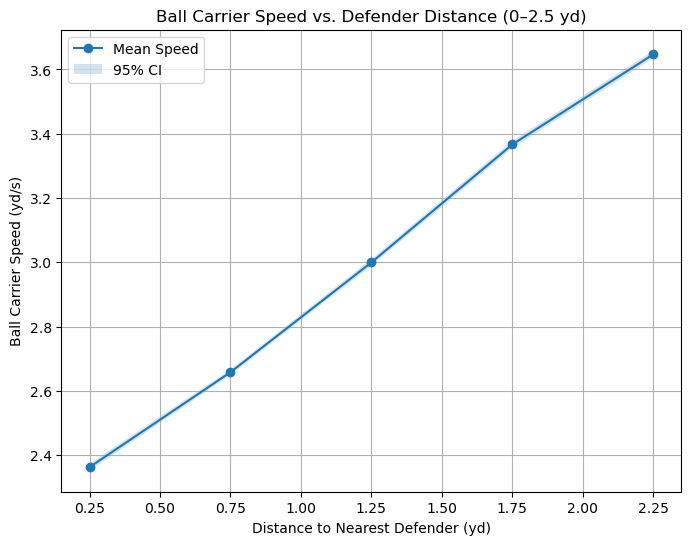

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('speed_dist_data_20231228.csv')
df = df[df['toPlayerNflId'] != 0]
df_2yd = df[df['toPlayerDistanceToBallCarrier'] <= 2.5].copy()

# Bin distances (0 to 2.5 yards, 5 bins for clarity)
bins = np.linspace(0, 2.5, 6)  # 0.5-yard intervals
df_2yd['dist_bin'] = pd.cut(df_2yd['toPlayerDistanceToBallCarrier'], bins, include_lowest=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Calculate mean speed and standard error per bin
speed_stats = df_2yd.groupby('dist_bin')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
speed_stats['se'] = speed_stats['std'] / np.sqrt(speed_stats['count'])
speed_stats['ci_lower'] = speed_stats['mean'] - 1.96 * speed_stats['se']
speed_stats['ci_upper'] = speed_stats['mean'] + 1.96 * speed_stats['se']

# Plot
plt.figure(figsize=(8, 6))
plt.plot(bin_centers, speed_stats['mean'], marker='o', label='Mean Speed')
plt.fill_between(bin_centers, speed_stats['ci_lower'], speed_stats['ci_upper'], alpha=0.2, label='95% CI')
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Ball Carrier Speed vs. Defender Distance (0–2.5 yd)')
plt.legend()
plt.grid(True)
plt.show()

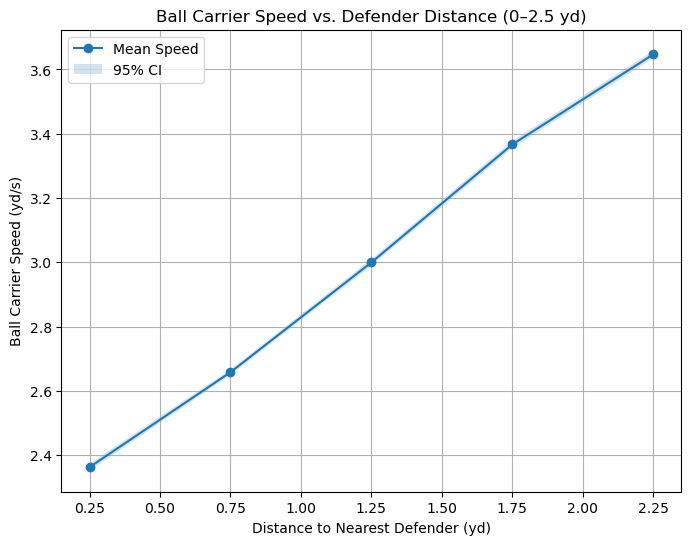

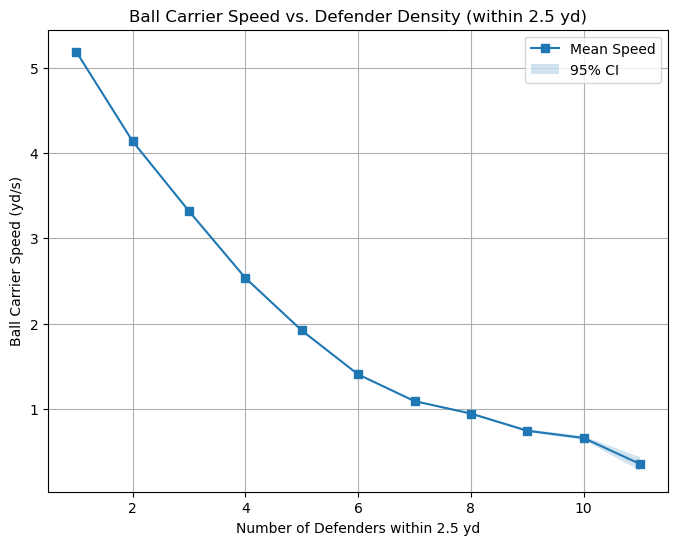

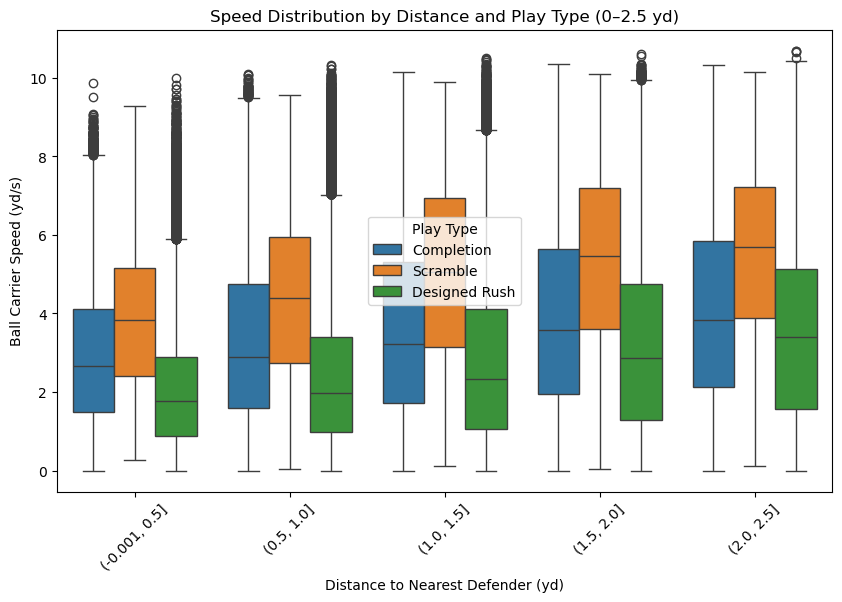

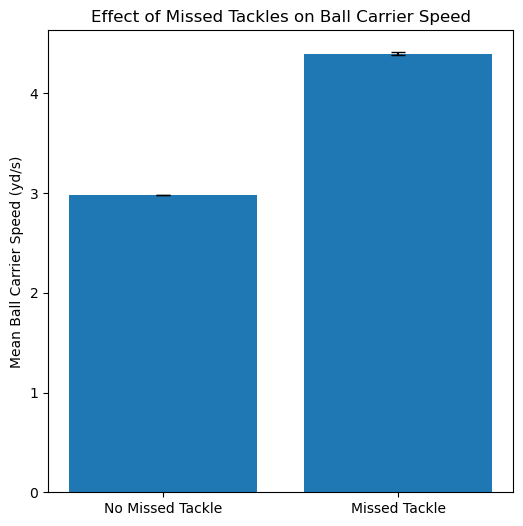

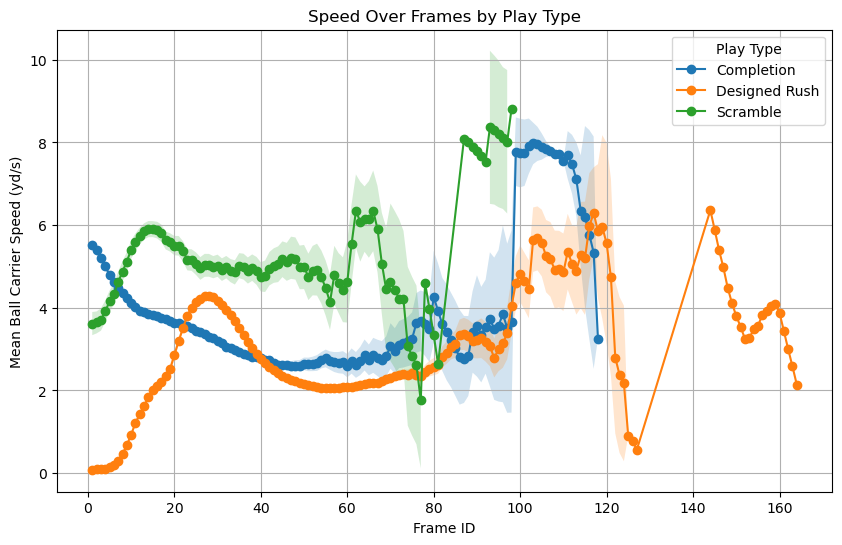

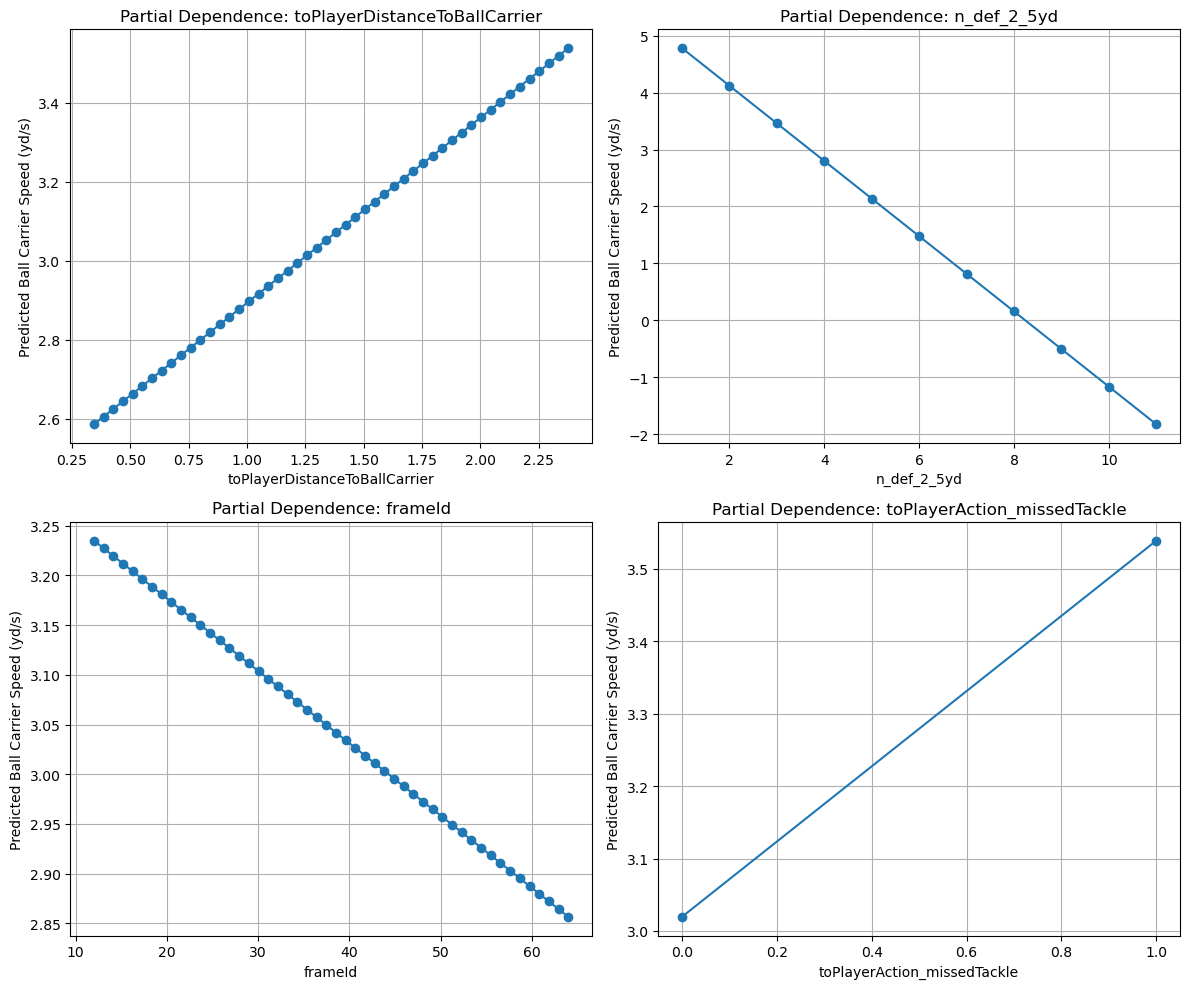

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import partial_dependence
from sklearn.linear_model import LinearRegression

# Load data
df = pd.read_csv('speed_dist_data_20231228.csv')
df = df[df['toPlayerNflId'] != 0]
df_2yd = df[df['toPlayerDistanceToBallCarrier'] <= 2.5].copy()

# Add n_def_2_5yd (from our model)
df_2yd['n_def_2_5yd'] = (
    df_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Bin distances (0 to 2.5 yards, 5 bins for clarity)
bins = np.linspace(0, 2.5, 6)  # 0.5-yard intervals
df_2yd['dist_bin'] = pd.cut(df_2yd['toPlayerDistanceToBallCarrier'], bins, include_lowest=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Visualization 1: Mean Speed vs. Defender Distance (Full Range with Confidence Intervals)
speed_stats = df_2yd.groupby('dist_bin', observed=True)['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
speed_stats['se'] = speed_stats['std'] / np.sqrt(speed_stats['count'])
speed_stats['ci_lower'] = speed_stats['mean'] - 1.96 * speed_stats['se']
speed_stats['ci_upper'] = speed_stats['mean'] + 1.96 * speed_stats['se']

plt.figure(figsize=(8, 6))
plt.plot(bin_centers, speed_stats['mean'], marker='o', label='Mean Speed')
plt.fill_between(bin_centers, speed_stats['ci_lower'], speed_stats['ci_upper'], alpha=0.2, label='95% CI')
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Ball Carrier Speed vs. Defender Distance (0–2.5 yd)')
plt.legend()
plt.grid(True)
plt.show()

# Visualization 2: Mean Speed vs. Defender Density (Using Model’s Range)
density_stats = df_2yd.groupby('n_def_2_5yd')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
density_stats['se'] = density_stats['std'] / np.sqrt(density_stats['count'])
density_stats['ci_lower'] = density_stats['mean'] - 1.96 * density_stats['se']
density_stats['ci_upper'] = density_stats['mean'] + 1.96 * density_stats['se']

plt.figure(figsize=(8, 6))
plt.plot(density_stats.index, density_stats['mean'], marker='s', label='Mean Speed')
plt.fill_between(density_stats.index, density_stats['ci_lower'], density_stats['ci_upper'], alpha=0.2, label='95% CI')
plt.xlabel('Number of Defenders within 2.5 yd')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Ball Carrier Speed vs. Defender Density (within 2.5 yd)')
plt.legend()
plt.grid(True)
plt.show()

# Visualization 3: Speed vs. Distance by Play Type (Full Range, Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='dist_bin', y='ballCarrierSpeed', hue='playType', data=df_2yd)
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Speed Distribution by Distance and Play Type (0–2.5 yd)')
plt.legend(title='Play Type')
plt.xticks(rotation=45)
plt.show()

# Visualization 4: Effect of Missed Tackles on Speed (Bar Plot with Error Bars)
missed_stats = df_2yd.groupby('toPlayerAction_missedTackle')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
missed_stats['se'] = missed_stats['std'] / np.sqrt(missed_stats['count'])

plt.figure(figsize=(6, 6))
plt.bar(['No Missed Tackle', 'Missed Tackle'], missed_stats['mean'], yerr=missed_stats['se'], capsize=5)
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Effect of Missed Tackles on Ball Carrier Speed')
plt.show()

# Visualization 5: Speed Over Frames by Play Type (Line Plot with Confidence Intervals)
frame_stats = df_2yd.groupby(['frameId', 'playType'], observed=True)['ballCarrierSpeed'].agg(['mean', 'std', 'count']).reset_index()
frame_stats['se'] = frame_stats['std'] / np.sqrt(frame_stats['count'])

plt.figure(figsize=(10, 6))
for ptype in frame_stats['playType'].unique():
    subset = frame_stats[frame_stats['playType'] == ptype]
    plt.plot(subset['frameId'], subset['mean'], marker='o', label=ptype)
    plt.fill_between(subset['frameId'], 
                     subset['mean'] - 1.96 * subset['se'], 
                     subset['mean'] + 1.96 * subset['se'], 
                     alpha=0.2)
plt.xlabel('Frame ID')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Speed Over Frames by Play Type')
plt.legend(title='Play Type')
plt.grid(True)
plt.show()

# Visualization 6: Partial Dependence Plot for Key Predictors
X = df_2yd[['toPlayerDistanceToBallCarrier', 'n_def_2_5yd', 'frameId', 'toPlayerAction_missedTackle']]
X = pd.get_dummies(X.join(df_2yd[['playType', 'gameId']]), columns=['playType', 'gameId'], drop_first=True)
y = df_2yd['ballCarrierSpeed']

model = LinearRegression()
model.fit(X, y)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
predictors_to_plot = ['toPlayerDistanceToBallCarrier', 'n_def_2_5yd', 'frameId', 'toPlayerAction_missedTackle']
for i, predictor in enumerate(predictors_to_plot):
    pd_results = partial_dependence(model, X, features=[predictor], grid_resolution=50)
    ax[i//2, i%2].plot(pd_results['grid_values'][0], pd_results['average'][0], marker='o')
    ax[i//2, i%2].set_title(f'Partial Dependence: {predictor}')
    ax[i//2, i%2].set_xlabel(predictor)
    ax[i//2, i%2].set_ylabel('Predicted Ball Carrier Speed (yd/s)')
    ax[i//2, i%2].grid(True)
plt.tight_layout()
plt.show()

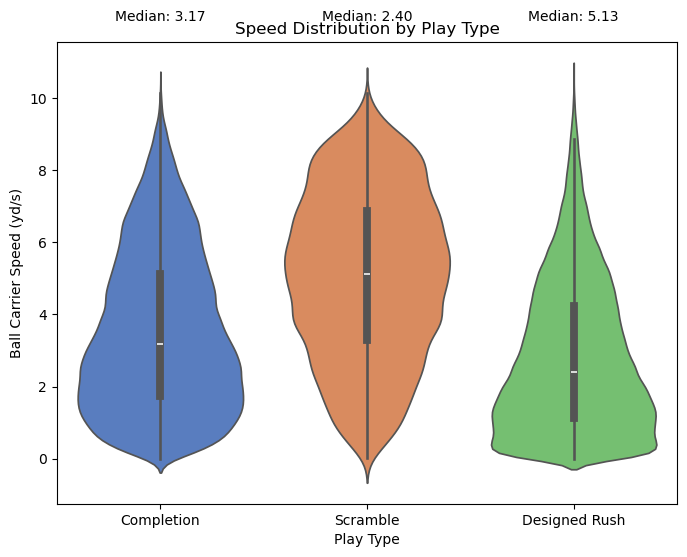

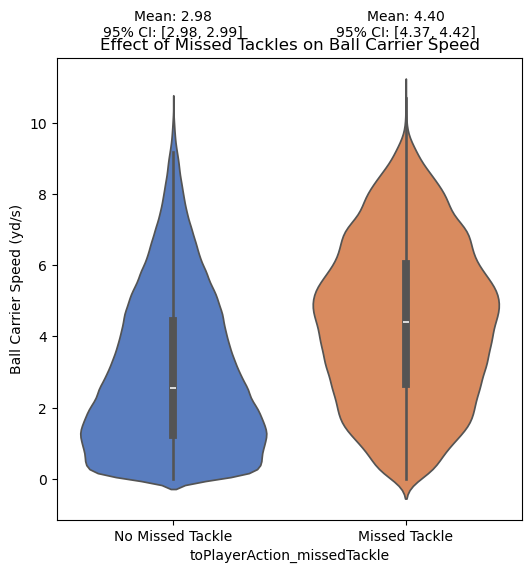

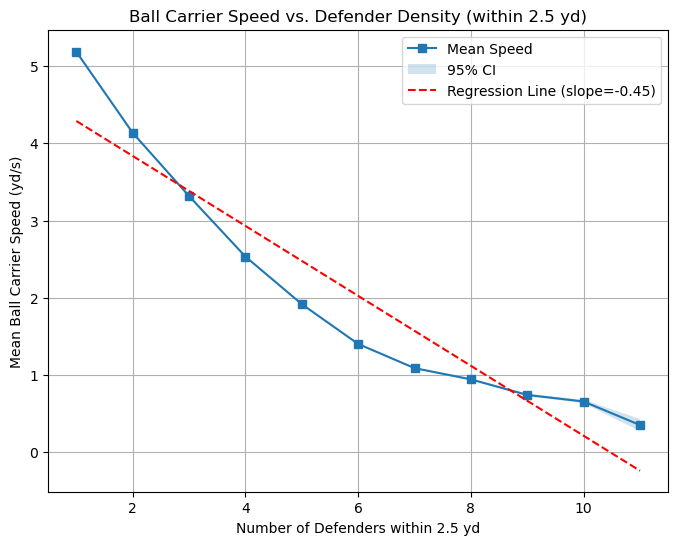

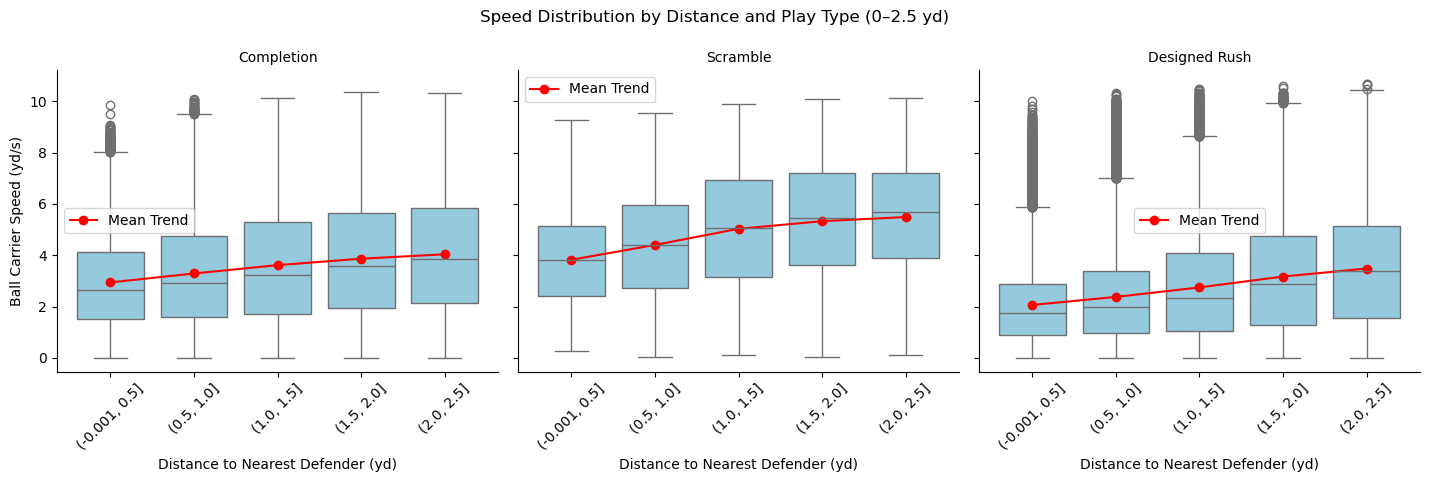

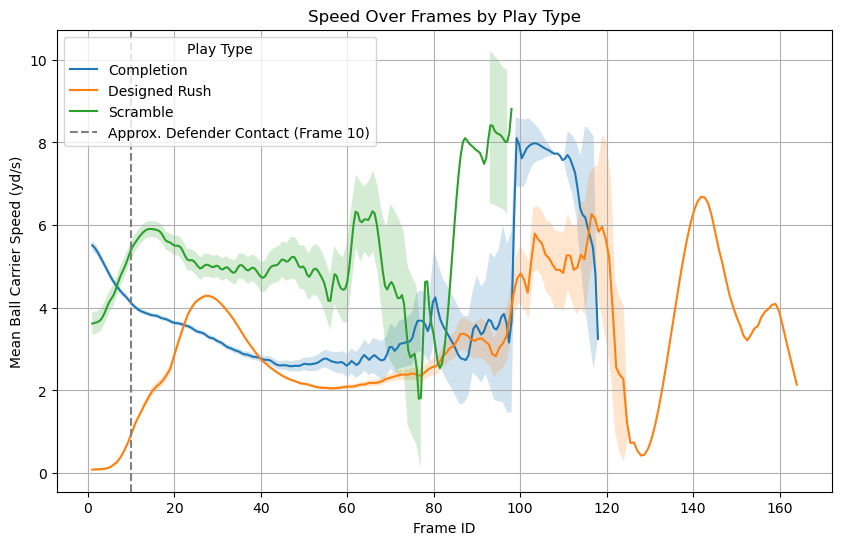

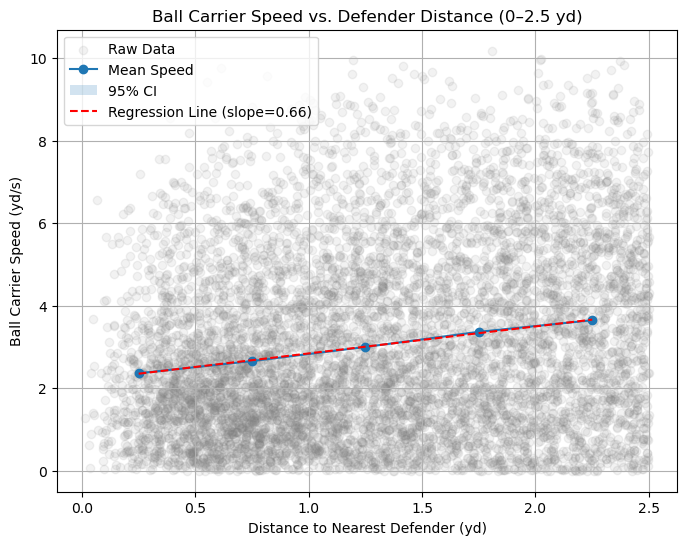

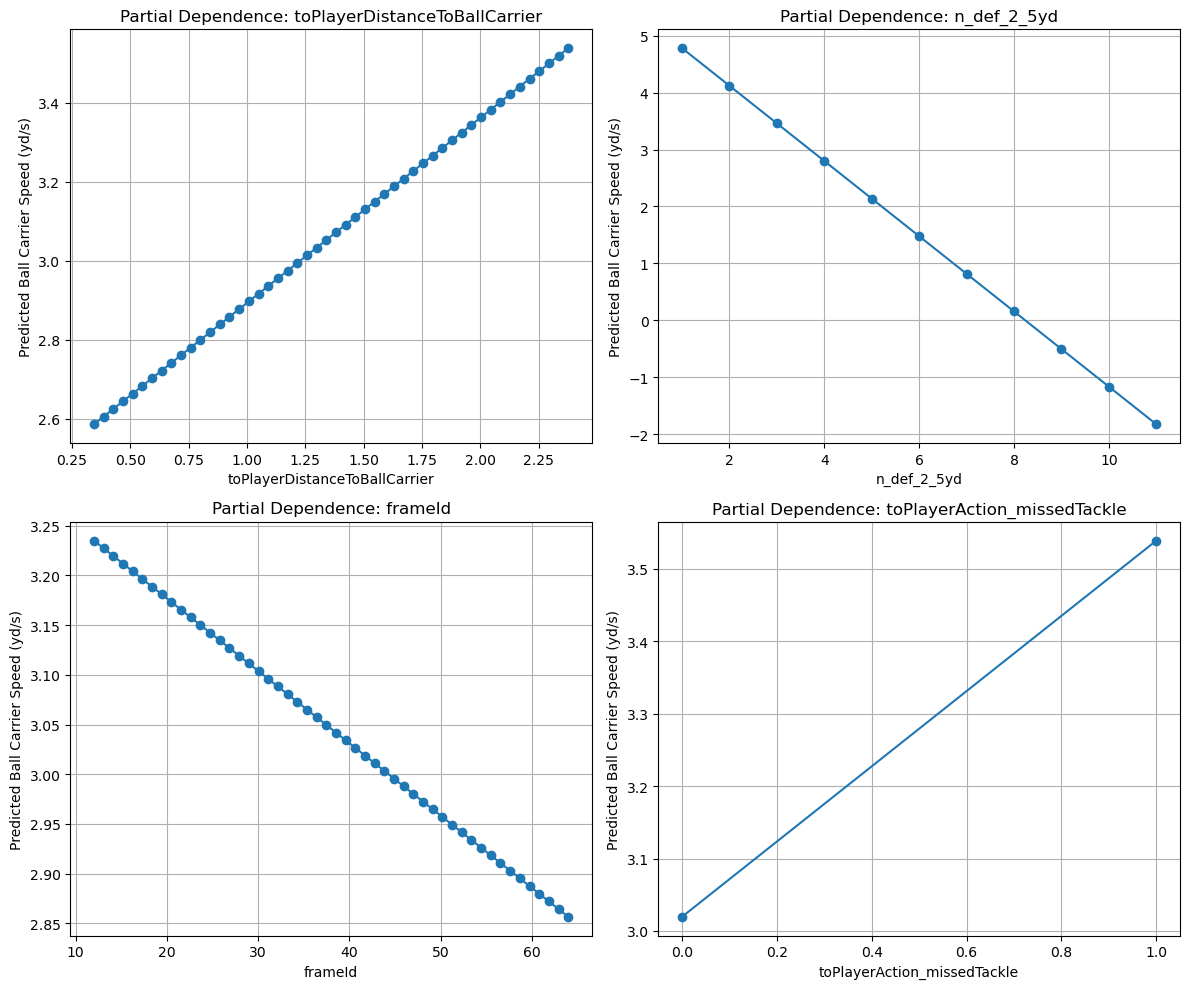

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import partial_dependence
from sklearn.linear_model import LinearRegression
import os
from scipy.interpolate import make_interp_spline

# Define the output folder for saving visuals
output_folder = './NFL_Visuals'
os.makedirs(output_folder, exist_ok=True)

# Load data
df = pd.read_csv('speed_dist_data_20231228.csv')
df = df[df['toPlayerNflId'] != 0]
df_2yd = df[df['toPlayerDistanceToBallCarrier'] <= 2.5].copy()

# Add n_def_2_5yd (from our model)
df_2yd['n_def_2_5yd'] = (
    df_2yd
    .groupby(['gameId', 'playId', 'frameId'])['toPlayerDistanceToBallCarrier']
    .transform(lambda d: (d <= 2.5).sum())
)

# Bin distances (0 to 2.5 yards, 5 bins for clarity)
bins = np.linspace(0, 2.5, 6)  # 0.5-yard intervals
df_2yd['dist_bin'] = pd.cut(df_2yd['toPlayerDistanceToBallCarrier'], bins, include_lowest=True)
bin_centers = (bins[:-1] + bins[1:]) / 2

# Visualization 0: Violin Plot of Ball Carrier Speed by Play Type with Median Annotations
plt.figure(figsize=(8, 6))
ax = sns.violinplot(x='playType', y='ballCarrierSpeed', hue='playType', data=df_2yd, palette='muted', legend=False)
# Calculate medians and annotate
medians = df_2yd.groupby('playType')['ballCarrierSpeed'].median()
# Get the maximum y-value for positioning text
y_max = ax.get_ylim()[1]
for i, median in enumerate(medians):
    ax.text(i, y_max + 0.5, f'Median: {median:.2f}', ha='center', va='bottom', fontsize=10, color='black')
plt.xlabel('Play Type')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Speed Distribution by Play Type')
plt.savefig(os.path.join(output_folder, 'speed_by_playtype_violin.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 2: Violin Plot of Missed Tackles Effect with Mean and CI Annotations
plt.figure(figsize=(6, 6))
ax = sns.violinplot(x='toPlayerAction_missedTackle', y='ballCarrierSpeed', hue='toPlayerAction_missedTackle', 
                    data=df_2yd, palette='muted', legend=False)
# Calculate means and standard errors
missed_stats = df_2yd.groupby('toPlayerAction_missedTackle')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
missed_stats['se'] = missed_stats['std'] / np.sqrt(missed_stats['count'])
missed_stats['ci_lower'] = missed_stats['mean'] - 1.96 * missed_stats['se']
missed_stats['ci_upper'] = missed_stats['mean'] + 1.96 * missed_stats['se']
# Get the maximum y-value for positioning text
y_max = ax.get_ylim()[1]
# Annotate means and CIs
for i, (mean, ci_lower, ci_upper) in enumerate(zip(missed_stats['mean'], missed_stats['ci_lower'], missed_stats['ci_upper'])):
    ax.text(i, y_max + 0.5, f'Mean: {mean:.2f}\n95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]', 
            ha='center', va='bottom', fontsize=10, color='black')
plt.xticks([0, 1], ['No Missed Tackle', 'Missed Tackle'])
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Effect of Missed Tackles on Ball Carrier Speed')
plt.savefig(os.path.join(output_folder, 'speed_vs_missed_tackle_violin.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 3: Speed vs. Defender Density with Regression Line and Markers
density_stats = df_2yd.groupby('n_def_2_5yd')['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
density_stats['se'] = density_stats['std'] / np.sqrt(density_stats['count'])
density_stats['ci_lower'] = density_stats['mean'] - 1.96 * density_stats['se']
density_stats['ci_upper'] = density_stats['mean'] + 1.96 * density_stats['se']

plt.figure(figsize=(8, 6))
# Plot mean speed with markers
plt.plot(density_stats.index, density_stats['mean'], marker='s', label='Mean Speed')
plt.fill_between(density_stats.index, density_stats['ci_lower'], density_stats['ci_upper'], alpha=0.2, label='95% CI')
# Add regression line
z = np.polyfit(density_stats.index, density_stats['mean'], 1)
p = np.poly1d(z)
plt.plot(density_stats.index, p(density_stats.index), "r--", label=f'Regression Line (slope={z[0]:.2f})')
plt.xlabel('Number of Defenders within 2.5 yd')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Ball Carrier Speed vs. Defender Density (within 2.5 yd)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_folder, 'speed_vs_density_with_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 4: Speed by Distance and Play Type with Facet Grid and Trend Lines
g = sns.FacetGrid(df_2yd, col="playType", col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.boxplot, x='dist_bin', y='ballCarrierSpeed', color='skyblue')
# Add trend lines
for ax, play_type in zip(g.axes.flat, df_2yd['playType'].unique()):
    subset = df_2yd[df_2yd['playType'] == play_type]
    speed_by_bin = subset.groupby('dist_bin', observed=True)['ballCarrierSpeed'].mean()
    ax.plot(range(len(speed_by_bin)), speed_by_bin.values, marker='o', color='red', label='Mean Trend')
    ax.legend()
g.set_axis_labels('Distance to Nearest Defender (yd)', 'Ball Carrier Speed (yd/s)')
g.set_titles('{col_name}')
g.set_xticklabels(rotation=45)
# Adjust the top margin to prevent overlap with the title
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Speed Distribution by Distance and Play Type (0–2.5 yd)', y=1.05)
plt.savefig(os.path.join(output_folder, 'speed_vs_distance_by_playtype_facet.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 5: Speed Over Frames by Play Type with Smoothed Lines and Key Frame Markers
frame_stats = df_2yd.groupby(['frameId', 'playType'], observed=True)['ballCarrierSpeed'].agg(['mean', 'std', 'count']).reset_index()
frame_stats['se'] = frame_stats['std'] / np.sqrt(frame_stats['count'])

plt.figure(figsize=(10, 6))
for ptype in frame_stats['playType'].unique():
    subset = frame_stats[frame_stats['playType'] == ptype]
    # Smooth the line using spline interpolation
    x = subset['frameId']
    y = subset['mean']
    if len(x) > 3:  # Need at least 4 points for spline
        x_smooth = np.linspace(x.min(), x.max(), 200)
        spl = make_interp_spline(x, y, k=3)
        y_smooth = spl(x_smooth)
        plt.plot(x_smooth, y_smooth, label=ptype)
    else:
        plt.plot(x, y, label=ptype)
    plt.fill_between(subset['frameId'], 
                     subset['mean'] - 1.96 * subset['se'], 
                     subset['mean'] + 1.96 * subset['se'], 
                     alpha=0.2)
# Add key frame markers (approximate defender contact or catch, e.g., frame 10)
plt.axvline(x=10, color='gray', linestyle='--', label='Approx. Defender Contact (Frame 10)')
plt.xlabel('Frame ID')
plt.ylabel('Mean Ball Carrier Speed (yd/s)')
plt.title('Speed Over Frames by Play Type')
plt.legend(title='Play Type')
plt.grid(True)
plt.savefig(os.path.join(output_folder, 'speed_vs_frame_by_playtype_smoothed.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 6: Speed vs. Defender Distance with Regression Line and Scatter Points
speed_stats = df_2yd.groupby('dist_bin', observed=True)['ballCarrierSpeed'].agg(['mean', 'std', 'count'])
speed_stats['se'] = speed_stats['std'] / np.sqrt(speed_stats['count'])
speed_stats['ci_lower'] = speed_stats['mean'] - 1.96 * speed_stats['se']
speed_stats['ci_upper'] = speed_stats['mean'] + 1.96 * speed_stats['se']

plt.figure(figsize=(8, 6))
# Scatter raw data points (subsampled for clarity)
subset = df_2yd.sample(frac=0.01, random_state=42)  # 1% of data for scatter
plt.scatter(subset['toPlayerDistanceToBallCarrier'], subset['ballCarrierSpeed'], alpha=0.1, color='gray', label='Raw Data')
# Plot mean speed with CI
plt.plot(bin_centers, speed_stats['mean'], marker='o', label='Mean Speed')
plt.fill_between(bin_centers, speed_stats['ci_lower'], speed_stats['ci_upper'], alpha=0.2, label='95% CI')
# Add regression line
z = np.polyfit(bin_centers, speed_stats['mean'], 1)
p = np.poly1d(z)
plt.plot(bin_centers, p(bin_centers), "r--", label=f'Regression Line (slope={z[0]:.2f})')
plt.xlabel('Distance to Nearest Defender (yd)')
plt.ylabel('Ball Carrier Speed (yd/s)')
plt.title('Ball Carrier Speed vs. Defender Distance (0–2.5 yd)')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(output_folder, 'speed_vs_distance_with_regression.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Visualization 7: Partial Dependence Plot for Key Predictors with Enhanced Labels
X = df_2yd[['toPlayerDistanceToBallCarrier', 'n_def_2_5yd', 'frameId', 'toPlayerAction_missedTackle']]
X = pd.get_dummies(X.join(df_2yd[['playType', 'gameId']]), columns=['playType', 'gameId'], drop_first=True)
y = df_2yd['ballCarrierSpeed']

model = LinearRegression()
model.fit(X, y)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
predictors_to_plot = ['toPlayerDistanceToBallCarrier', 'n_def_2_5yd', 'frameId', 'toPlayerAction_missedTackle']
for i, predictor in enumerate(predictors_to_plot):
    pd_results = partial_dependence(model, X, features=[predictor], grid_resolution=50)
    ax[i//2, i%2].plot(pd_results['grid_values'][0], pd_results['average'][0], marker='o')
    ax[i//2, i%2].set_title(f'Partial Dependence: {predictor}')
    ax[i//2, i%2].set_xlabel(predictor)
    ax[i//2, i%2].set_ylabel('Predicted Ball Carrier Speed (yd/s)')
    ax[i//2, i%2].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_folder, 'partial_dependence_plots.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# 1) Load & filter
df = pd.read_csv('speed_dist_data_20231228.csv',
                 dtype={'gameId':'int32','playId':'int32','frameId':'int16'})
df = df[df.toPlayerNflId != 0]
df = df[df.toPlayerDistanceToBallCarrier <= 2.5].copy()
df['ballCarrierSpeed'] = pd.to_numeric(df.ballCarrierSpeed, errors='coerce')
df = df.dropna(subset=['ballCarrierSpeed'])
df['n_def_2_5yd'] = (
    df.groupby(['gameId','playId','frameId'])
      .toPlayerDistanceToBallCarrier
      .transform(lambda d: (d<=2.5).sum())
)

# 2) Sample & split
sample = df.sample(n=50000, random_state=42)
X = sample[['toPlayerDistanceToBallCarrier','n_def_2_5yd','frameId','toPlayerAction_missedTackle']]
y = sample['ballCarrierSpeed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3) Fit Linear Regression
lr = LinearRegression().fit(X_train, y_train)
y_lr = lr.predict(X_test)

# 4) Fit Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1).fit(X_train, y_train)
y_rf = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

# … after predictions …
rmse_lr = root_mean_squared_error(y_test, y_lr)
rmse_rf = root_mean_squared_error(y_test, y_rf)
mae_lr  = mean_absolute_error  (y_test, y_lr)
mae_rf  = mean_absolute_error  (y_test, y_rf)
r2_lr   = r2_score             (y_test, y_lr)
r2_rf   = r2_score             (y_test, y_rf)

# Then assemble your results DataFrame as before
import pandas as pd
results = pd.DataFrame({
    'Model': ['LinearRegression','RandomForest'],
    'RMSE' : [rmse_lr, rmse_rf],
    'MAE'  : [mae_lr,  mae_rf ],
    'R2'   : [r2_lr,   r2_rf  ]
})
print(results)


              Model      RMSE       MAE        R2
0  LinearRegression  1.708073  1.369784  0.373882
1      RandomForest  1.767746  1.369665  0.329370


In [20]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ======================
# 1. Data Loading & Prep 
# ======================
try:
    # Load with memory-efficient dtypes
    dtypes = {
        'gameId': 'int32', 'playId': 'int32', 'frameId': 'int16',
        'toPlayerNflId': 'int32', 'ballCarrierSpeed': 'float32'
    }
    data = pd.read_csv('speed_dist_data_20231228.csv', dtype=dtypes)
    
    # Filter and clean
    data = data[data['toPlayerNflId'] != 0]
    data_2yd = data[data['toPlayerDistanceToBallCarrier'] <= 2.5].copy()
    data_2yd['ballCarrierSpeed'] = pd.to_numeric(
        data_2yd['ballCarrierSpeed'], errors='coerce'
    ).astype('float32')
    data_2yd.dropna(subset=['ballCarrierSpeed'], inplace=True)
    
    # Downcast numerics
    for col in data_2yd.select_dtypes(include=['float64']):
        data_2yd[col] = pd.to_numeric(data_2yd[col], downcast='float')
    for col in data_2yd.select_dtypes(include=['int64']):
        data_2yd[col] = pd.to_numeric(data_2yd[col], downcast='integer')

except Exception as e:
    raise Exception(f"Data loading error: {e}")

# ======================
# 2. Feature Engineering
# ======================
# Defender count (vectorized)
data_2yd['n_def_2_5yd'] = (
    data_2yd.eval('toPlayerDistanceToBallCarrier <= 2.5').groupby(
        [data_2yd['gameId'], data_2yd['playId'], data_2yd['frameId']]
    ).transform('sum')
)

# Key predictors (updated for missed tackle prediction)
predictors = [
    'ballCarrierSpeed',
    'toPlayerDistanceToBallCarrier',
    'n_def_2_5yd',
    'frameId'
]

# Binary target
data_2yd['missed_tackle'] = data_2yd['toPlayerAction_missedTackle'].astype('int8')

# ======================
# 3. Logistic Regression Model (Corrected Clustering)
# ======================
# Add intercept and prep data
X = sm.add_constant(data_2yd[predictors])
y = data_2yd['missed_tackle']

# Fit GLM with Binomial family (logistic regression)
logit_model = sm.GLM(
    y, X,
    family=sm.families.Binomial()
).fit(cov_type='cluster', cov_kwds={'groups': data_2yd['playId']})

print("\n=== Logistic Regression Results ===")
print(logit_model.summary())

# ======================
# 4. Model Diagnostics
# ======================
# VIF check
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\n=== VIF Analysis ===")
print(vif_data)

# Class balance
print("\n=== Class Balance ===")
print(f"Missed Tackle Rate: {y.mean():.2%}")

# Odds Ratios (for interpretation)
print("\n=== Odds Ratios ===")
print(pd.DataFrame({
    'Variable': X.columns,
    'Odds Ratio': np.exp(logit_model.params),
    'p-value': logit_model.pvalues
}).round(4))


=== Logistic Regression Results ===
                 Generalized Linear Model Regression Results                  
Dep. Variable:          missed_tackle   No. Observations:               754558
Model:                            GLM   Df Residuals:                   754553
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.2065e+05
Date:                Tue, 29 Apr 2025   Deviance:                   2.4130e+05
Time:                        15:43:47   Pearson chi2:                 7.75e+05
No. Iterations:                     7   Pseudo R-squ. (CS):            0.02622
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------